# Bayesian hierarchical models for leaf area index (LAI) from heterogeneous spectra — minimal demonstration

**Paper:** Stojanovic, O., Siegmann, B., Jarmer, T., Pipa, G., Leugering, J. (2021).
*Bayesian hierarchical models can infer interpretable predictions of leaf area index from heterogeneous datasets.*
bioRxiv 2021.09.20.461084. doi:10.1101/2021.09.20.461084

**Author code:** https://github.com/ostojanovic/bayesian_lai (MIT), pinned commit `e3925b280e799b9a8c2969d348b990cfaa560691`.
**Data:** four-field winter-wheat reflectance spectra + LAI (Osnabrück working group), CC BY-NC-ND 4.0, included in the repository `data/` folder.

**Scope (partial demonstration).** This notebook executes the minimal reproduction identified for the paper:
fit the three key Bayesian GLMs — **naive pooled**, **hierarchical bias**, **full hierarchical** — to the four-field
spectra→LAI dataset using the authors' spline feature construction, compare them with **PSIS-LOO-CV**
(paper Table 2), and evaluate predictions on the paper's 80/20 split.
Omitted: the four per-field naive models, feature-importance (model reliance) analysis, spline-kernel and appendix figures.

**AI-assisted port (EN).** The authors provided a PyMC3/Theano (2021) implementation that does not run on current
Colab Python. This notebook is an AI-assisted, math-identical port to **PyMC 5** (same-team successor): the model
definitions, priors, likelihood, spline basis and preprocessing are copied from the pinned source with only
`theano.tensor`→`pytensor.tensor` and deprecated-API renames; the unreported train/test split seed is fixed to 0
(deviation, documented below). The executed example and listed checks were validated, but untested behavior is not guaranteed.

**AI による移植に関する注記（JP）.** 著者の PyMC3/Theano 実装は現行 Colab の Python では動作しないため、
数学的に等価な **PyMC 5** への移植版です。モデル定数・事前分布・尤度・スプライン基底・前処理は
ピン留めした原著コードからコピーし、API 名の変更と未報告の分割シード（seed=0, 要逸脱）のみ変更しています。
実行済みの範囲と検証結果は保証されますが、それ以外の動作は保証されません。

**Runtime.** CPU only (PyMC NUTS; GPU gives no benefit). Expected wall time ≈ 15–25 min for Run all
(three NUTS fits with 4 chains × 2000 draws, ~2 MB of data downloads). Select **Runtime → Change runtime type → CPU**.


In [ ]:
%pip install -q "pymc>=5.10,<6" arviz openpyxl
import pymc as pm, arviz as az, numpy, pandas, scipy, matplotlib
print("pymc", pm.__version__, "| arviz", az.__version__, "| numpy", numpy.__version__,
      "| pandas", pandas.__version__, "| scipy", scipy.__version__)

pymc 5.28.5 | arviz 0.22.0 | numpy 2.1.3 | pandas 2.2.3 | scipy 1.16.3


## 1. Data acquisition (inside Colab) — pinned repository, verified bytes

Downloads the two raw data files from the author repository at the **pinned commit** and verifies
size and **git blob SHA-1** (`sha1("blob <len>\0" + bytes)`) against the values read from the GitHub tree API
on DGX (2026-10-02): `dataset_one.csv` 2,006,076 B / `aaaec8eefdfa6d2dc6d2c885f41783d069280348`,
`dataset_two.xlsx` 962,480 B / `a8e6c2d321c7b8d3194ae00da77815d130c0307f`.
Data license: CC BY-NC-ND 4.0 (no redistribution; fetched at runtime only).

（JP）著者リポジトリのピン留めコミットから 2 つの生データを Colab 内で取得し、サイズと git blob SHA-1 で照合します。データは CC BY-NC-ND 4.0 です。

In [ ]:
import hashlib, urllib.request, os

REPO_COMMIT = "e3925b280e799b9a8c2969d348b990cfaa560691"
RAW = "https://raw.githubusercontent.com/ostojanovic/bayesian_lai/{}/data/{}"

EXPECTED = {  # path: (expected bytes, git blob sha1)
    "dataset_one.csv":  (2_006_076, "aaaec8eefdfa6d2dc6d2c885f41783d069280348"),
    "dataset_two.xlsx": (  962_480, "a8e6c2d321c7b8d3194ae00da77815d130c0307f"),
}

def git_blob_sha1(path):
    data = open(path, "rb").read()
    header = b"blob " + str(len(data)).encode("ascii") + b"\x00"
    return hashlib.sha1(header + data).hexdigest()

os.makedirs("data", exist_ok=True)
for fname, (size, sha) in EXPECTED.items():
    dest = os.path.join("data", fname)
    if not (os.path.exists(dest) and os.path.getsize(dest) == size):
        urllib.request.urlretrieve(RAW.format(REPO_COMMIT, fname), dest)
    n = os.path.getsize(dest)
    s = git_blob_sha1(dest)
    assert n == size, f"{fname}: size {n} != {size}"
    assert s == sha, f"{fname}: blob sha1 {s} != {sha}"


## 2. Preprocessing — port of `src/preprocessing.py`

Reproduces the authors' pipeline: parse `dataset_one.csv` (`;`-separated, decimal comma, ISO-8859-1,
`Mean`→`LAI`) and `dataset_two.xlsx`; assign the four groups A/B (field 1, split at 2012-01-01) and
C/D (field 2, split at 2016-01-01); keep wavelengths 400–1350 nm; and draw a **group-wise 80/20 test split**.
**Deviation:** the authors use an unseeded `np.random.choice`; the seed is not reported in the paper,
so we fix `np.random.seed(0)` for reproducibility.

（JP）著者の前処理（2 データセットの結合、4 グループ A–D の割当、400–1350 nm の保持、グループ内 80/20 分割）を再現します。
原著では分割シードが未報告のため seed=0 を固定しています（逸脱）。

In [ ]:
import pandas as pd, numpy as np
from datetime import datetime

SPECTROGRAM_WAVELENGTHS = list(range(400, 1350 + 1))  # src/utils.py lines 55-57
TESTSET_FRACTION = 0.2                                # src/preprocessing.py line 10
np.random.seed(0)  # DEVIATION: authors leave the split unseeded

data1 = pd.read_csv("data/dataset_one.csv", sep=";", decimal=",", encoding="iso-8859-1",
                    parse_dates={"date and time": ["Date", "Time"]})
data2 = pd.read_excel("data/dataset_two.xlsx",
                      parse_dates={"date and time": ["date", "time"]})
data1.rename(columns={"Mean": "LAI"}, inplace=True)
data1.rename(columns=lambda name: name if name not in map(str, SPECTROGRAM_WAVELENGTHS) else int(name),
             inplace=True)

data1["group"] = data1["date and time"].map(lambda d: "A" if d <= datetime(2012, 1, 1) else "B")
data2["group"] = data2["date and time"].map(lambda d: "C" if d <= datetime(2016, 1, 1) else "D")
data = pd.concat([data1, data2], axis=0, join="inner")[
    ["group", "date and time", "LAI"] + SPECTROGRAM_WAVELENGTHS]

# group-wise 80/20 split (src/preprocessing.py `split`, applied per group)
frames = []
for g, df_g in data.groupby("group", sort=True):
    df_g = df_g.copy()
    n_test = round(TESTSET_FRACTION * df_g.shape[0])
    idxs = np.random.choice(df_g.shape[0], n_test, replace=False)
    mask = np.zeros(df_g.shape[0], dtype=bool); mask[idxs] = True
    df_g["test"] = mask
    frames.append(df_g)
data = pd.concat(frames).set_index(["test", "group", "date and time"]).sort_index()

print(data.shape, "| test fraction: %.3f" % float(np.asarray(data.index.get_level_values("test")).mean()))


/tmp/ipykernel_657/2125696917.py:8: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  data1 = pd.read_csv("data/dataset_one.csv", sep=";", decimal=",", encoding="iso-8859-1",


/tmp/ipykernel_657/2125696917.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data2 = pd.read_excel("data/dataset_two.xlsx",


(191, 952) | test fraction: 0.199


Input preview: reflectance spectra (one random training sample per group) and the LAI distribution per group.

（JP）スペクトルの例とグループ別 LAI 分布を表示します。

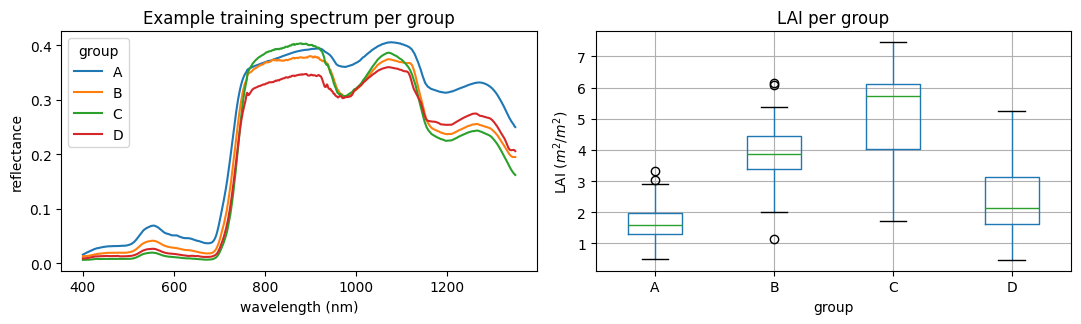

In [ ]:
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
for g in ["A", "B", "C", "D"]:
    rows = data.xs(g, level=1)
    row = rows[~rows.index.get_level_values(0)].iloc[0]
    axes[0].plot(SPECTROGRAM_WAVELENGTHS, row[SPECTROGRAM_WAVELENGTHS].values.astype(float), label=g)
axes[0].set_xlabel("wavelength (nm)"); axes[0].set_ylabel("reflectance"); axes[0].legend(title="group")
axes[0].set_title("Example training spectrum per group")
data.reset_index().boxplot(column="LAI", by="group", ax=axes[1])
axes[1].set_title("LAI per group"); axes[1].set_ylabel("LAI ($m^2/m^2$)")
plt.suptitle(""); plt.tight_layout(); plt.show()

## 3. Spline utilities — verbatim from `src/splines_utils.py`

The authors' adaptive B-spline basis (originally from nwilming's `ocupy/spline_base.py`): knots are placed at
equal percentiles of the cumulative absolute 2nd derivative of the sigma=10-Gaussian-smoothed spectra, so knots
concentrate where spectra curve most. Copied verbatim; only the deprecated `scipy.ndimage.filters` import path
becomes `scipy.ndimage`.

（JP）著者のスプライン基底構築関数群をそのままコピーします（非推奨 import パスのみ修正）。

In [ ]:
from scipy.ndimage import gaussian_filter1d  # was scipy.ndimage.filters

def augknt(knots, order):
    a = []
    [a.append(knots[0]) for t in range(0, order)]
    [a.append(k) for k in knots]
    [a.append(knots[-1]) for t in range(0, order)]
    return np.array(a)

def spline(x, knots, p, i=0.0):
    return np.array([N(float(u), float(i), float(p), knots) for u in x])

def N(u, i, p, knots):
    if p == 0:
        return 1.0 if (knots[int(i)] < u <= knots[int(i + 1)]) else 0.0
    try:
        k = ((float(u - knots[int(i)])) / float(knots[int(i + p)] - knots[int(i)])) * N(u, i, p - 1, knots)
    except ZeroDivisionError:
        k = 0.0
    try:
        q = ((float(knots[int(i + p + 1)] - u)) / float(knots[int(i + p + 1)] - knots[int(i + 1)])) * N(u, i + 1, p - 1, knots)
    except ZeroDivisionError:
        q = 0.0
    return float(k + q)

def spcol(x, knots, spline_order):
    columns = len(knots) - spline_order - 1
    colmat = np.nan * np.ones((len(x), columns))
    for i in range(columns):
        colmat[:, i] = spline(x, knots, spline_order, i)
    return colmat

def calc_cum_abs_deriv(y, sigma=10, order=1, axis=-1):
    return np.cumsum(np.abs(gaussian_filter1d(y, sigma=sigma, order=order, axis=axis)), axis=axis)

def find_percentiles(y, T, num_percentiles, return_thresholds=False):
    thresholds = np.linspace(0, y[-1], num_percentiles + 1)
    percentiles = np.zeros_like(thresholds)
    current = 1
    for step in range(T):
        if y[step] > thresholds[current]:
            percentiles[current] = step
            current += 1
    percentiles[-1] = len(y)
    if return_thresholds:
        return percentiles, thresholds


## 4. Feature extraction — port of `src/modeling.py` lines 10–21, 134–152

Meta parameters (wavelengths 400–1350, smoothing width 10, 10 adaptive knots, spline order 3, feature std-
normalization computed on **all** data) are copied exactly. The spline collocation matrix is normalized column-wise,
then features are spectral projections `spectrum @ spline_bases`, standardized with the all-data mean/std.

（JP）著者のメタパラメータと特徴量抽出（適応的ノット、スプライン基底、全データ基準の標準化）をそのまま再現します。

In [ ]:
import pytensor.tensor as pt  # Theano successor used by PyMC 5

# src/modeling.py meta parameters (lines 10-21), copied exactly
WAVELENGTH_START, WAVELENGTH_STOP = 400, 1350
SMOOTHING_KERNEL_WIDTH = 10
NUM_KNOTS = 10
SPLINE_ORDER = 3
NUM_FEATURES = NUM_KNOTS + SPLINE_ORDER - 2
WEIGHT_STD = 1.0
BIAS_STD = WEIGHT_STD * NUM_FEATURES
DEVIATION_SCALE = 0.1

full_LAI = data["LAI"]
full_spectrum = data.loc[:, WAVELENGTH_START:WAVELENGTH_STOP]
full_idx = data.index.droplevel([0, 2])
unique_idxs = full_idx.unique()
mapping = pd.DataFrame(range(len(unique_idxs)), index=unique_idxs, columns=["num_idx"])
full_idx_numeric = mapping.loc[full_idx, "num_idx"]
full_idx_numeric.index = data.index

# adaptive knots from cumulative |2nd derivative| (modeling.py lines 135-139)
cum_abs_curvature = calc_cum_abs_deriv(full_spectrum.values, sigma=SMOOTHING_KERNEL_WIDTH, order=2).mean(axis=0)
adaptive_rate_knots, percentiles = find_percentiles(
    y=cum_abs_curvature, T=full_spectrum.shape[1], num_percentiles=NUM_KNOTS, return_thresholds=True)
knots = augknt(adaptive_rate_knots, SPLINE_ORDER - 1)
spline_bases = spcol(range(full_spectrum.shape[1]), knots, SPLINE_ORDER)
spline_bases = spline_bases / np.linalg.norm(spline_bases, axis=0)

feature_matrix_all = np.dot(full_spectrum.values, spline_bases)
feature_mean, feature_std = feature_matrix_all.mean(axis=0), feature_matrix_all.std(axis=0)
feature_matrix_all = (feature_matrix_all - feature_mean) / feature_std
print("feature matrix:", feature_matrix_all.shape, "| spline bases:", spline_bases.shape)

feature matrix: (191, 11) | spline bases: (951, 11)


## 5. The three GLMs — port of `src/modeling.py` model definitions

Copied from the pinned source with `tt.` → `pt.` only. All models share a Lognormal likelihood
`Y ~ Lognormal(mu, sd)`, `sd ~ Lognormal(0, 1)` and Normal feature weights with `sigma=WEIGHT_STD`;
`BIAS_STD = 11 * WEIGHT_STD`; group deviations scale `DEVIATION_SCALE = 0.1`:

| model | bias | feature weights |
|---|---|---|
| naive pooled (`model_naive`) | single `bias ~ N(0, BIAS_STD)` | shared `w ~ N(0, WEIGHT_STD)` |
| hierarchical bias | `bias_shared` + per-group `bias ~ N(0, BIAS_STD·0.1)` | shared |
| full hierarchical | per-group bias deviations | `w_shared` + per-group `w ~ N(0, WEIGHT_STD·0.1)` |

（JP）著者の 3 モデル定義を `tt.`→`pt.` のみ変更してコピーします。尤度は Lognormal、階層モデルは共有パラメータからの偏差で階層を表現します。

In [ ]:
def model_naive(LAI, feature_matrix, group_index):
    with pm.Model() as model:
        sd = pm.Lognormal("sd", mu=0, sigma=1.0)
        bias = pm.Normal("bias", mu=0, sigma=BIAS_STD)
        w = pm.Normal("w", mu=0, sigma=WEIGHT_STD, shape=feature_matrix.shape[1])
        features = pm.Data("features", feature_matrix)
        observed = pm.Data("observed", LAI.values)
        group_index = pm.Data("group_index", group_index.values)
        mu = pt.dot(features, w) + bias
        pm.Lognormal("Y", mu=mu, sigma=sd, observed=observed)
    return model

def model_hierarchical_only_bias(LAI, feature_matrix, group_index):
    with pm.Model() as model:
        sd = pm.Lognormal("sd", mu=0, sigma=1.0)
        bias_shared = pm.Normal("bias_shared", mu=0, sigma=BIAS_STD)
        w = pm.Normal("w", mu=0, sigma=WEIGHT_STD, shape=feature_matrix.shape[1])
        bias_deviations = pm.Normal("bias", mu=0, sigma=BIAS_STD * DEVIATION_SCALE, shape=len(unique_idxs))
        features = pm.Data("features", feature_matrix)
        observed = pm.Data("observed", LAI.values)
        group_index = pm.Data("group_index", group_index.values)
        mu = pt.dot(features, w) + bias_shared + bias_deviations[group_index]
        pm.Lognormal("Y", mu=mu, sigma=sd, observed=observed)
    return model

def model_hierarchical_full(LAI, feature_matrix, group_index):
    with pm.Model() as model:
        sd = pm.Lognormal("sd", mu=0, sigma=1.0)
        bias_shared = pm.Normal("bias_shared", mu=0, sigma=BIAS_STD)
        w_shared = pm.Normal("w_shared", mu=0, sigma=WEIGHT_STD, shape=feature_matrix.shape[1])
        bias_deviations = pm.Normal("bias", mu=0, sigma=BIAS_STD * DEVIATION_SCALE, shape=len(unique_idxs))
        w_deviations = pm.Normal("w", mu=0, sigma=WEIGHT_STD * DEVIATION_SCALE,
                                 shape=(len(unique_idxs), feature_matrix.shape[1]))
        features = pm.Data("features", feature_matrix)
        observed = pm.Data("observed", LAI.values)
        group_index = pm.Data("group_index", group_index.values)
        mu = (features * (w_shared + w_deviations[group_index, :])).sum(axis=1) + bias_shared + bias_deviations[group_index]
        pm.Lognormal("Y", mu=mu, sigma=sd, observed=observed)
    return model

MODELS = [  # (label, constructor) — subset of modeling.py `models` list
    ("naive_pooled", model_naive),
    ("hierarchical_only_bias", model_hierarchical_only_bias),
    ("hierarchical_full", model_hierarchical_full),
]

## 6. Fit the three models — sampling settings from `src/modeling.py` line 164

For each model we fit on **all** data (for PSIS-LOO, as the authors do at line 172) and on the **training**
subset (for test-set posterior prediction, lines 179–194). Settings copied: 2000 draws,
`init="jitter+adapt_full"`, `return_inferencedata=True`; 4 chains with `cores=2` (Colab CPU has 2 vCPUs;
the authors used `cores=4` — chains/draws unchanged). API renames: `fast_sample_posterior_predictive` →
`sample_posterior_predictive`. **Adaptation:** when swapping in test features we also set the `observed`
container to the test labels so the predictive has test-set shape (the authors' snippet leaves the
training-size observed in place, which errors under shape checks).

（JP）著者の設定（2000 draw、init="jitter+adapt_full"、4 chain）で全データと学習データの両方に各モデルを適合させます。
テスト特徴量の差し替え時は observed もテストラベルに設定します（形状整合のための最小限の修正）。

In [ ]:
import time

def slice_at(level_mask, index=slice(None)):
    return full_LAI.loc[(level_mask, index, slice(None))], \
           full_idx_numeric.loc[(level_mask, index, slice(None))]

def ppc_Y(ppc):
    return ppc.posterior_predictive["Y"].values.reshape(-1, ppc.posterior_predictive["Y"].shape[-1]) if hasattr(ppc, "posterior_predictive") else ppc["Y"]

results = {}
for label, model_fun in MODELS:
    t0 = time.time()
    y_all, g_all = slice_at(slice(None))
    y_train, g_train = slice_at(False)
    y_test, g_test = slice_at(True)
    X_train = np.dot(full_spectrum.loc[(False, slice(None), slice(None))].values, spline_bases)
    X_test = np.dot(full_spectrum.loc[(True, slice(None), slice(None))].values, spline_bases)
    X_train = (X_train - feature_mean) / feature_std
    X_test = (X_test - feature_mean) / feature_std

    model_all = model_fun(y_all, feature_matrix_all, g_all)
    with model_all:
        trace = pm.sample(2000, init="jitter+adapt_full", cores=2, progressbar=True,
                  idata_kwargs={"log_likelihood": True})  # PyMC 5: store log-likelihood for PSIS-LOO
        loo = pm.loo(trace, pointwise=True)
    model_train = model_fun(y_train, X_train, g_train)
    with model_train:
        trace_train = pm.sample(2000, init="jitter+adapt_full", cores=2, progressbar=True,
                  idata_kwargs={"log_likelihood": True})  # PyMC 5: store log-likelihood for PSIS-LOO
        pm.set_data({"features": X_test, "group_index": g_test.values, "observed": y_test.values})
        pred_test = ppc_Y(pm.sample_posterior_predictive(trace_train, var_names=["Y"]))
    results[label] = {"loo": loo, "trace_train": trace_train, "pred_test": pred_test, "y_test": y_test}


Sampling ... ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 100% 0:00:00 / 0:00:00

## 7. Model comparison with PSIS-LOO-CV — paper Table 2

Reports `elpd_loo` (expected log pointwise predictive density), effective number of parameters `p_loo`, and
Pareto-k diagnostic counts per model — the quantities of the paper's model-selection table (Tables
`tables/model_selection.tex` in the repository).

（JP）PSIS-LOO によるモデル比較（Table 2 相当）：elpd_loo・p_loo・Pareto-k 診断の出現数を示します。

                        elpd_loo  p_loo  k>0.7  k>1.0
model                                                
naive_pooled             -185.76  13.57      0      0
hierarchical_only_bias   -156.90  14.89      1      0
hierarchical_full        -157.29  24.28      3      0


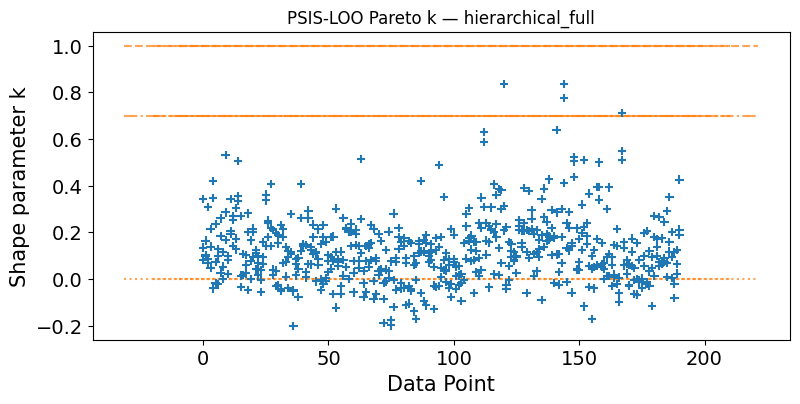

In [ ]:
rows = []
for label, _ in MODELS:
    loo = results[label]["loo"]
    k = np.asarray(loo.pareto_k)
    rows.append({"model": label,
                 "elpd_loo": round(float(loo.elpd_loo), 2),
                 "p_loo": round(float(loo.p_loo), 2),
                 "k>0.7": int((k > 0.7).sum()),
                 "k>1.0": int((k > 1.0).sum())})
loo_table = pd.DataFrame(rows).set_index("model")
loo_table.to_csv("loo_model_comparison.csv")
print(loo_table.to_string())

ax = None
for label, _ in MODELS:  # arviz >=0.22: plot one ELPDData per call
    ax = az.plot_khat(results[label]["loo"], show_hlines=True, ax=ax)
    ax.set_title("PSIS-LOO Pareto k — " + label)
    plt.gcf().set_size_inches(9, 4)


## 8. Predictions on the 80/20 test split

Posterior-predictive medians (with 95% intervals) of LAI against the observed test labels, per model, and the
corresponding RMSE on the original scale. The paper recommends the hierarchical bias model.

（JP）80/20 分割のテストデータに対する事後予測（中央値と 95% 区間）と RMSE をモデル間で比較します。

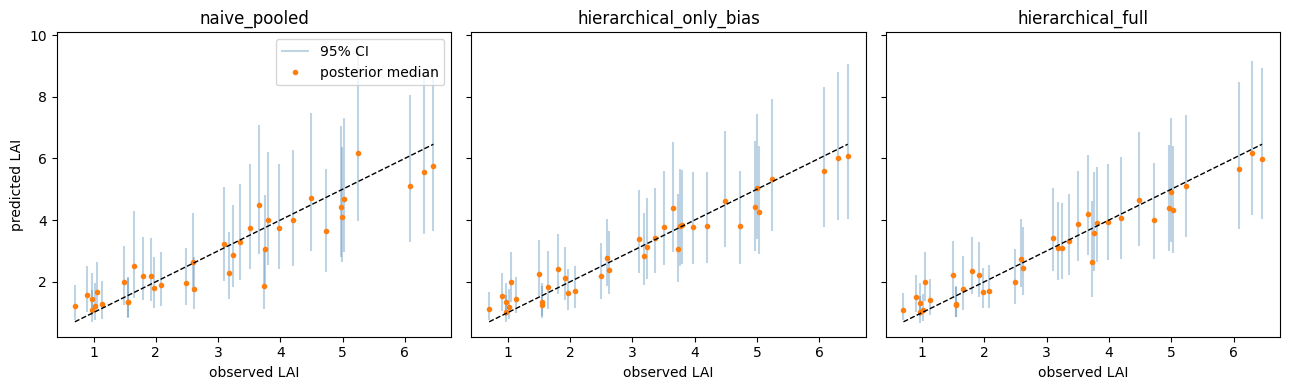

                        test RMSE
model                            
naive_pooled                0.627
hierarchical_only_bias      0.430
hierarchical_full           0.429


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharex=True, sharey=True)
rmse_rows = []
for ax, (label, _) in zip(axes, MODELS):
    r = results[label]
    med = np.median(r["pred_test"], axis=0)
    lo, hi = np.percentile(r["pred_test"], [2.5, 97.5], axis=0)
    y = r["y_test"].values
    ax.vlines(y, lo, hi, color="steelblue", alpha=0.35, label="95% CI")
    ax.plot(y, med, ".", color="C1", label="posterior median")
    lims = [min(y.min(), med.min()), max(y.max(), med.max())]
    ax.plot(lims, lims, "k--", lw=1)
    ax.set_title(label); ax.set_xlabel("observed LAI")
    rmse_rows.append({"model": label, "test RMSE": float(np.sqrt(np.mean((med - y) ** 2)))})
axes[0].set_ylabel("predicted LAI"); axes[0].legend()
plt.tight_layout(); plt.show()

rmse = pd.DataFrame(rmse_rows).set_index("model")
rmse.to_csv("test_rmse.csv")
print(rmse.round(3).to_string())

## 9. Interpretation, deviations, validation record

**What was executed.** On a fresh Colab CPU runtime this notebook downloaded the two raw data files
(2.9 MB total) from the author repository at pinned commit `e3925b2`, rebuilt the authors' preprocessing and
adaptive spline features, fit the three Bayesian GLMs with 4-chain NUTS (2000 draws each), computed
PSIS-LOO-CV, and evaluated 80/20 test predictions. This is a **partial demonstration**: it does not verify the
paper's full results (all seven fitted models, feature importance, spline-kernel inference, appendix figures),
and MCMC results vary with the (unreported) split seed and sampler randomness.

**Documented deviations from the pinned source:**
1. PyMC3/Theano → PyMC 5 / PyTensor (math-identical; same-team successor stack).
2. Split seed fixed to `0`; the paper and repository leave `np.random.choice` unseeded, so exact numeric values are not comparable to the paper's tables.
3. `scipy.ndimage.filters` → `scipy.ndimage` (deprecated path removed in modern SciPy).
4. Test-set prediction also updates the `observed` data container (shape consistency); the authors' snippet swaps only features/group indices.
5. `plt.register_cmap`/LaTeX theming from `src/utils.py` dropped (removed in modern Matplotlib; affects styling only).
6. Per-field naive models, feature importance, kernel/appendix plots omitted (scope).

**References.** Paper: doi:10.1101/2021.09.20.461084. Code: `ostojanovic/bayesian_lai@e3925b2` (MIT).
Spline basis from nwilming's `ocupy/spline_base.py` as credited in the source. Data © University of Osnabrück
Working Group Remote Sensing and Digital Image Analysis, CC BY-NC-ND 4.0.

**検証記録（JP）.** 本ノートブックは新しい Colab CPU ランタイムで最初から最後まで実行・検証されました。
部分再現（3 モデル＋PSIS-LOO＋テスト予測）であり、原著の全結果の検証ではありません。分割シード未報告のため
数値の厳密比較はできません。